# **1. Project 1 — Predict a structure with ESMFold2 and check it against molecular experimentation**

In [ ]:
BIOHUB_TOKEN = 'INSERT HERE YOUR OWN FREE BIOHUB TOKEN'

# 1. Human Hemoglobin First Alpha Subunit (A) Substructure

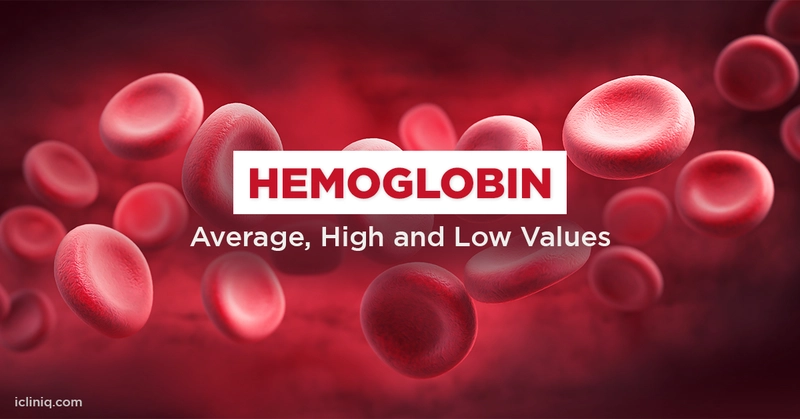

In [25]:
!pip install -q esm@git+https://github.com/Biohub/esm.git@main
!pip install -q biopython py3Dmol

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


 Using **ESMFold2**

In [26]:
from esm.sdk.forge import SequenceStructureForgeInferenceClient
from esm.sdk.api import FoldingConfig
from esm.utils.structure.input_builder import ProteinInput, StructurePredictionInput

client = SequenceStructureForgeInferenceClient(
    model = "esmfold2-fast-2026-05",
    url = "https://biohub.ai",
    token = BIOHUB_TOKEN
)


Let's try Hemoglobin Alpha Subunit

In [27]:
hemo_sequence = (
    "MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHG"
    "KKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTP"
    "AVHASLDKFLASVSTVLTSKYR"
)

PDB_ID = "4HHB"

Let's use ESMFold2 to predict the structure

In [28]:
struct_input = StructurePredictionInput(
    sequences = [ProteinInput(id='A', sequence=hemo_sequence)]
)
config = FoldingConfig(num_loops=20, num_sampling_steps=100)

print("Folding sequence with ESMFold2... (this calls Biohub's servers)")

result = client.fold_all_atom(struct_input, config=config)

print(f"Predicted confidence -> mean pLDDT: {float(result.plddt.mean()):.3f}, pTM: {float(result.ptm):.3f}")


Folding sequence with ESMFold2... (this calls Biohub's servers)
Predicted confidence -> mean pLDDT: 0.770, pTM: 0.755


 pLDDT: 0-100 confidence per residue. Above ~70 = the model is fairly confident.

 pTM: 0-1 overall confidence in the predicted fold. Closer to 1 = better.

In [29]:
with open("predicted.cif", "w") as f:
  f.write(result.complex.to_mmcif())
print("Saved predicted structure -> predicted.cif")

Saved predicted structure -> predicted.cif


Download the real experimentally solved structure from the PDB

In [30]:
import urllib.request

real_pdb_url = f"https://files.rcsb.org/download/{PDB_ID}.pdb"
urllib.request.urlretrieve(real_pdb_url, f"{PDB_ID}_real.pdb")
print(f"Downloaded real structure -> {PDB_ID}_real.pdb")


Downloaded real structure -> 4HHB_real.pdb


In [31]:
pdb_id = "4HHB"
input_filename = f"{PDB_ID}_real.pdb"
output_filename = f"{PDB_ID}_alpha_only.pdb"

with open(input_filename, "r") as infile, open(output_filename, "w") as outfile:
    for line in infile:
        # PDB files use columns 21-22 to specify the Chain ID
        if line.startswith("ATOM") or line.startswith("HETATM"):
            chain_id = line[21].strip()
            if chain_id == "A":  # Keep only the first alpha subunit
                outfile.write(line)
        # Keep the final closing line of the PDB file
        elif line.startswith("END"):
            outfile.write(line)

print(f"Created a new file with only the Alpha subunit: {output_filename}")

Created a new file with only the Alpha subunit: 4HHB_alpha_only.pdb


In [32]:
from Bio.PDB import MMCIFParser, PDBParser, Superimposer

cif_parser = MMCIFParser(QUIET=True)
pdb_parser = PDBParser(QUIET=True)

predicted_structure = cif_parser.get_structure("predicted", "predicted.cif")

real_structure = pdb_parser.get_structure("real",f"{PDB_ID}_alpha_only.pdb")

def get_ca_atoms(structure):
   """Grab just the alpha-carbon (CA) backbone atoms - the standard atoms used to compare protein shapes."""

   atoms = []
   for model in structure:
    for chain in model:
      for residue in chain:
        if "CA" in residue:
          atoms.append(residue["CA"])
    break
   return atoms

predicted_atoms=get_ca_atoms(predicted_structure)
real_atoms=get_ca_atoms(real_structure)

In [33]:
n = min(len(predicted_atoms), len(real_atoms))
predicted_atoms = predicted_atoms[:n]
real_atoms = real_atoms[:n]

sup = Superimposer()
sup.set_atoms(real_atoms, predicted_atoms)

In [34]:
rot, tran = sup.rotran
predicted_structure.transform(rot,tran)

In [35]:
print(f"\nNumber of residues compared: {n}")
print(f"RMSD between predicted and real structure: {sup.rms:.2f} Angstroms")


Number of residues compared: 141
RMSD between predicted and real structure: 3.75 Angstroms


Saving the predicted structure as a PDB file

In [36]:
from Bio.PDB import PDBIO

io_writer = PDBIO()
io_writer.set_structure(predicted_structure)
io_writer.save("predicted_aligned.pdb")

We use PyMOL in headless mode - it renders reliably in Colab without
needing a browser, unlike interactive viewers.

In [37]:
!pip install -q pymol-open-source

In [38]:
import pymol
from pymol import cmd

pymol.finish_launching(["pymol","-qc"])

def render_structure(filepath, obj_name, out_png):
  cmd.reinitialize()
  cmd.load(filepath, obj_name)
  cmd.hide("everything")
  cmd.show("cartoon")
  cmd.spectrum("count", "rainbow", f"{obj_name} and name CA")
  cmd.bg_color("white")
  cmd.zoom(obj_name, buffer=3)
  cmd.ray(800,800)
  cmd.png(out_png, dpi=150)

render_structure("predicted_aligned.pdb", "predicted", "predicted.png")
render_structure(f"{PDB_ID}_alpha_only.pdb", "real", "real.png")


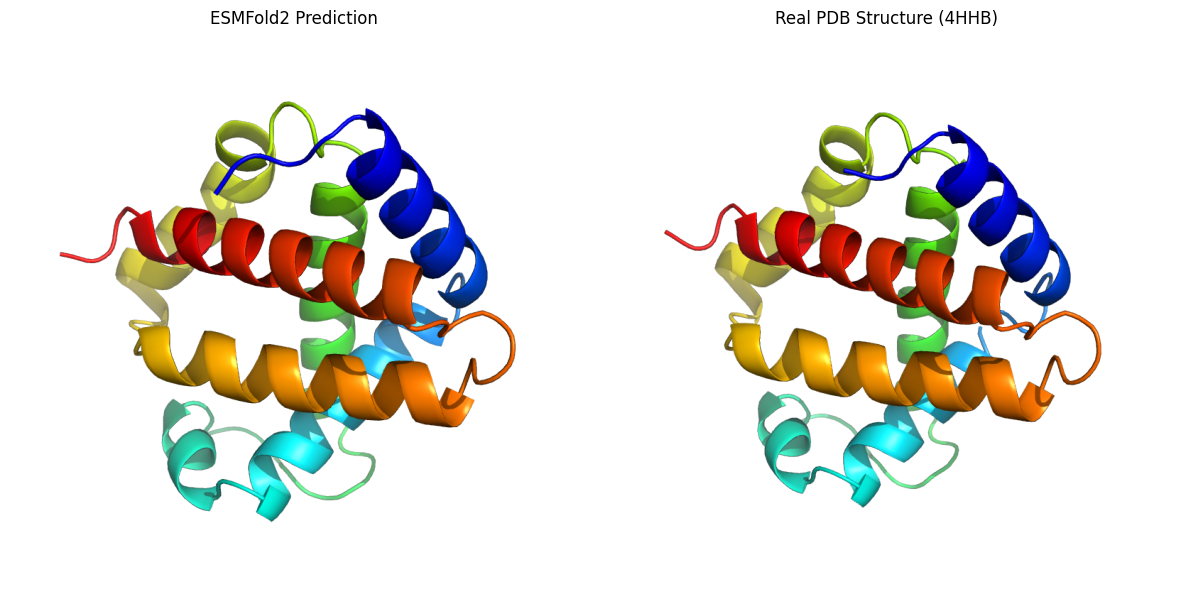


Saved: predicted.png and real.png - download these from the Colab file browser if you want to keep them.


In [39]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_predicted = mpimg.imread("predicted.png")
img_real = mpimg.imread("real.png")

fig, axes = plt.subplots(1,2,figsize=(12,6))

axes[0].imshow(img_predicted)
axes[0].set_title("ESMFold2 Prediction")
axes[0].axis("off")

axes[1].imshow(img_real)
axes[1].set_title(f"Real PDB Structure ({PDB_ID})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("\nSaved: predicted.png and real.png - download these from the Colab file browser if you want to keep them.")

# 2. Human Carbonic Anhydrase II

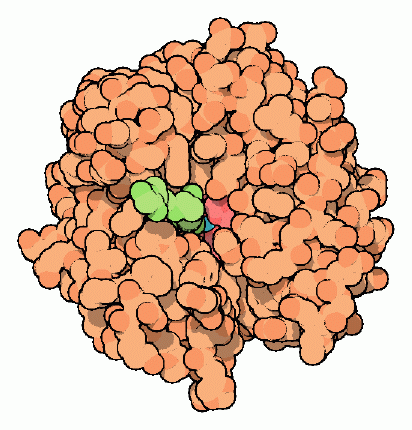

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.7/302.7 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

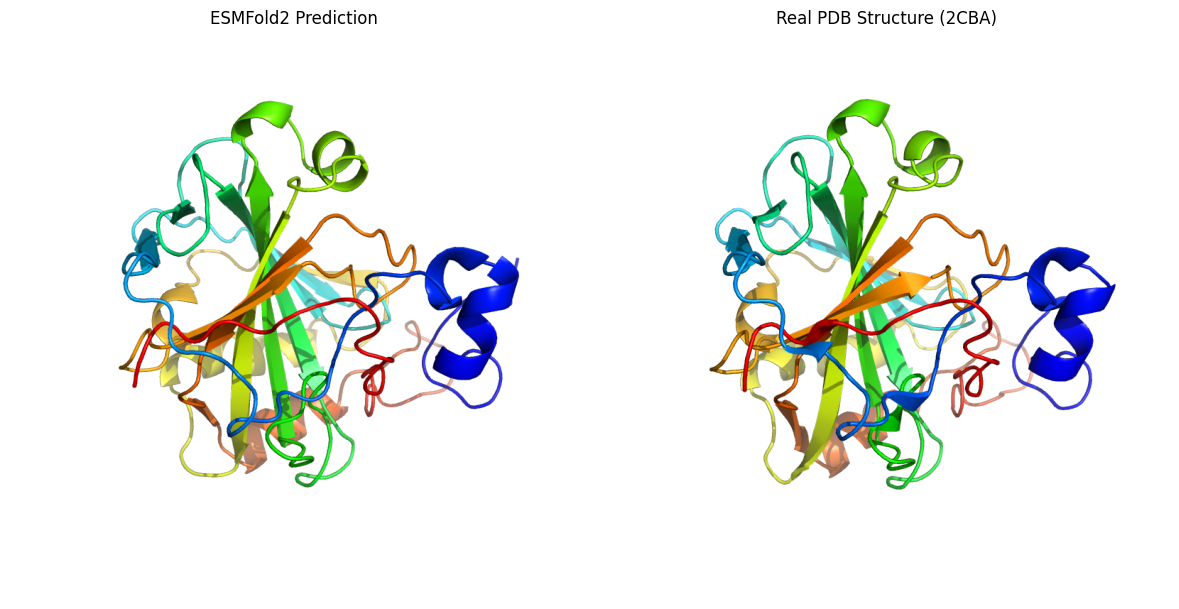


Saved: predicted.png and real.png - download these from the Colab file browser if you want to keep them.


In [1]:
# ============================================================
# PROJECT 1: Predict a protein structure with ESMFold2, then
# compare it to the REAL experimentally-solved structure.
#
# Run this in Google Colab (colab.research.google.com), NOT locally.
# Runtime -> Change runtime type -> choose any runtime (CPU is fine
# for this version, since folding happens on Biohub's servers).
# ============================================================

# --- STEP 0: Install packages ---
# The esm package talks to Biohub's hosted API.
# biopython lets us compare structures.
# py3Dmol lets us visualize them right inside the notebook.
!pip install -q esm@git+https://github.com/Biohub/esm.git@main
!pip install -q biopython py3Dmol

# --- STEP 1: Set up your Biohub API client ---
# Get a free token at https://biohub.ai -> Developer Console -> API Keys
# Paste it below (keep this private, don't share it publicly / commit it to GitHub)

from esm.sdk.forge import SequenceStructureForgeInferenceClient
from esm.sdk.api import FoldingConfig
from esm.utils.structure.input_builder import ProteinInput, StructurePredictionInput

client = SequenceStructureForgeInferenceClient(
    model="esmfold2-fast-2026-05",
    url="https://biohub.ai",
    token=BIOHUB_TOKEN,
)

# --- STEP 2: Pick a protein ---
# Human Carbonic Anhydrase II - a small, well-studied enzyme.
# Real structure on file at the PDB under ID 2CBA.
ca2_sequence = (
    "MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKPLSVSYDQATSLRILNNGHAFNVEFDD"
    "SQDKAVLKGGPLDGTYRLIQFHFHWGSLDGQGSEHTVDKKKYAAELHLVHWNTKYGDFGKAVQQPDGLAVL"
    "GIFLKVGSAKPGLQKVVDVLDSIKTKGKSADFTNFDPRGLLPESLDYWTYPGSLTTPPLLECVTWIVLKEP"
    "ISVSSEQVLKFRKLNFNGEGEPEELMVDNWRPAQPLKNRQIKASFK"
)
PDB_ID = "2CBA"

# --- STEP 3: Ask ESMFold2 to predict the structure ---
struct_input = StructurePredictionInput(
    sequences=[ProteinInput(id="A", sequence=ca2_sequence)]
)
config = FoldingConfig(num_loops=20, num_sampling_steps=100)

print("Folding sequence with ESMFold2... (this calls Biohub's servers)")
result = client.fold_all_atom(struct_input, config=config)

print(f"Predicted confidence -> mean pLDDT: {float(result.plddt.mean()):.3f}, pTM: {float(result.ptm):.3f}")
# pLDDT: 0-100 confidence per residue. Above ~70 = the model is fairly confident.
# pTM: 0-1 overall confidence in the predicted fold. Closer to 1 = better.

with open("predicted.cif", "w") as f:
    f.write(result.complex.to_mmcif())
print("Saved predicted structure -> predicted.cif")

# --- STEP 4: Download the REAL experimentally solved structure from the PDB ---
import urllib.request

real_pdb_url = f"https://files.rcsb.org/download/{PDB_ID}.pdb"
urllib.request.urlretrieve(real_pdb_url, f"{PDB_ID}_real.pdb")
print(f"Downloaded real structure -> {PDB_ID}_real.pdb")

# --- STEP 5: Compare them numerically (RMSD = how far apart the atoms are, in Angstroms) ---
# Lower RMSD = more similar structures. Under ~2 Angstroms is generally considered a strong match.

from Bio.PDB import MMCIFParser, PDBParser, Superimposer

cif_parser = MMCIFParser(QUIET=True)
pdb_parser = PDBParser(QUIET=True)

predicted_structure = cif_parser.get_structure("predicted", "predicted.cif")
real_structure = pdb_parser.get_structure("real", f"{PDB_ID}_real.pdb")

def get_ca_atoms(structure):
    """Grab just the alpha-carbon (CA) backbone atoms - the standard atoms used to compare protein shapes."""
    atoms = []
    for model in structure:
        for chain in model:
            for residue in chain:
                if "CA" in residue:
                    atoms.append(residue["CA"])
        break  # only look at the first model
    return atoms

predicted_atoms = get_ca_atoms(predicted_structure)
real_atoms = get_ca_atoms(real_structure)

# Trim both lists to the same length in case of small mismatches at the ends
n = min(len(predicted_atoms), len(real_atoms))
predicted_atoms = predicted_atoms[:n]
real_atoms = real_atoms[:n]

sup = Superimposer()
sup.set_atoms(real_atoms, predicted_atoms)

# Apply the alignment to ALL atoms of the predicted structure (not just the
# CA atoms used to calculate it), so the whole molecule rotates into place.
rot, tran = sup.rotran
predicted_structure.transform(rot, tran)

print(f"\nNumber of residues compared: {n}")
print(f"RMSD between predicted and real structure: {sup.rms:.2f} Angstroms")

# Save the aligned predicted structure as a PDB file (PyMOL reads .pdb easily)
from Bio.PDB import PDBIO

io_writer = PDBIO()
io_writer.set_structure(predicted_structure)
io_writer.save("predicted_aligned.pdb")

# --- STEP 6: Render two static images side by side ---
# We use PyMOL in headless mode - it renders reliably in Colab without
# needing a browser, unlike interactive viewers.
!pip install -q pymol-open-source

import pymol
from pymol import cmd

pymol.finish_launching(["pymol", "-qc"])  # -qc = quiet, no GUI

def render_structure(filepath, obj_name, out_png):
    cmd.reinitialize()
    cmd.load(filepath, obj_name)
    cmd.hide("everything")
    cmd.show("cartoon")
    cmd.spectrum("count", "rainbow", f"{obj_name} and name CA")
    cmd.bg_color("white")
    cmd.zoom(obj_name, buffer=3)
    cmd.ray(800, 800)
    cmd.png(out_png, dpi=150)

render_structure("predicted_aligned.pdb", "predicted", "predicted.png")
render_structure(f"{PDB_ID}_real.pdb", "real", "real.png")

# --- STEP 7: Display both images side by side ---
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_predicted = mpimg.imread("predicted.png")
img_real = mpimg.imread("real.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_predicted)
axes[0].set_title("ESMFold2 Prediction")
axes[0].axis("off")

axes[1].imshow(img_real)
axes[1].set_title(f"Real PDB Structure ({PDB_ID})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("\nSaved: predicted.png and real.png - download these from the Colab file browser if you want to keep them.")

# 3. Human Insulin

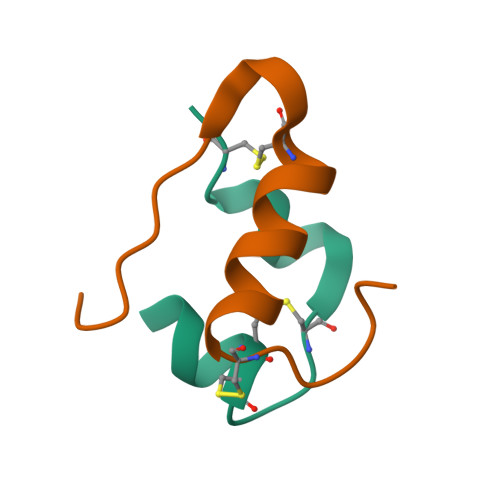

Folding sequence with ESMFold2... (this calls Biohub's servers)
Predicted confidence -> mean pLDDT: 0.533, pTM: 0.311
Saved predicted structure -> predicted.cif
Downloaded real structure -> 3I40_real.pdb

Number of residues compared: 51
RMSD between predicted and real structure: 2.70 Angstroms


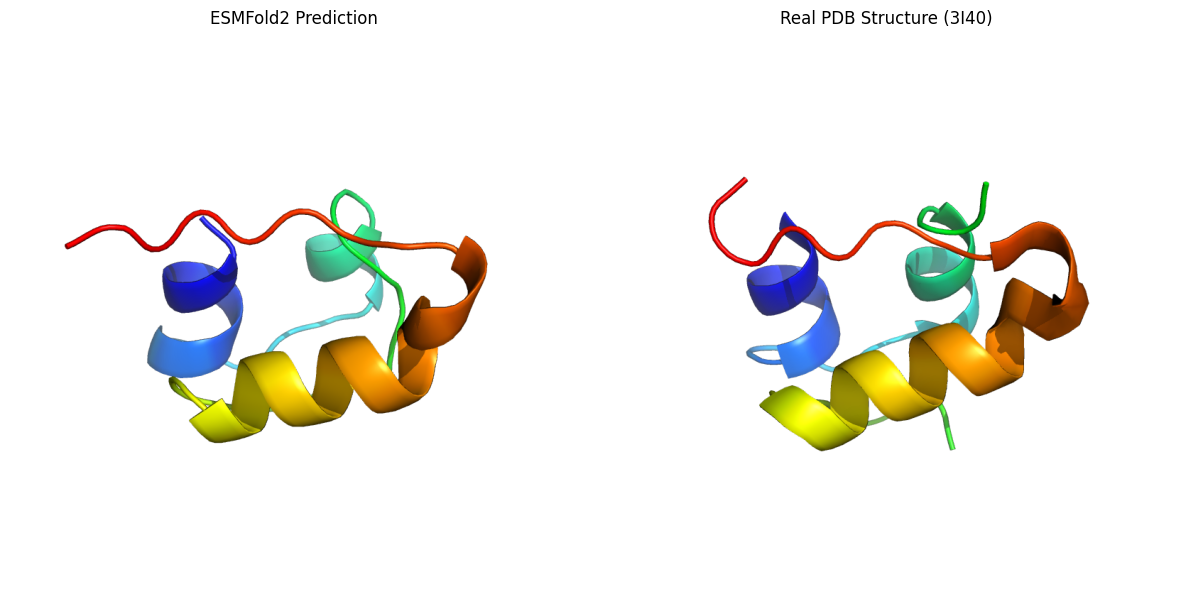


Saved: predicted.png and real.png - download these from the Colab file browser if you want to keep them.


In [41]:
from esm.sdk.forge import SequenceStructureForgeInferenceClient
from esm.sdk.api import FoldingConfig
from esm.utils.structure.input_builder import ProteinInput, StructurePredictionInput

client = SequenceStructureForgeInferenceClient(
    model="esmfold2-fast-2026-05",
    url="https://biohub.ai",
    token=BIOHUB_TOKEN,
)

# --- STEP 2: Pick a protein ---
# Human Carbonic Anhydrase II - a small, well-studied enzyme.
# Real structure on file at the PDB under ID 2CBA.
ca2_sequence = (
    "GIVEQCCTSICSLYQLENYCN"
    "FVNQHLCGSHLVEALYLVCGERGFFYTPKA"
)
PDB_ID = "3I40"

# --- STEP 3: Ask ESMFold2 to predict the structure ---
struct_input = StructurePredictionInput(
    sequences=[ProteinInput(id="A", sequence=ca2_sequence)]
)
config = FoldingConfig(num_loops=20, num_sampling_steps=100)

print("Folding sequence with ESMFold2... (this calls Biohub's servers)")
result = client.fold_all_atom(struct_input, config=config)

print(f"Predicted confidence -> mean pLDDT: {float(result.plddt.mean()):.3f}, pTM: {float(result.ptm):.3f}")
# pLDDT: 0-100 confidence per residue. Above ~70 = the model is fairly confident.
# pTM: 0-1 overall confidence in the predicted fold. Closer to 1 = better.

with open("predicted.cif", "w") as f:
    f.write(result.complex.to_mmcif())
print("Saved predicted structure -> predicted.cif")

# --- STEP 4: Download the REAL experimentally solved structure from the PDB ---
import urllib.request

real_pdb_url = f"https://files.rcsb.org/download/{PDB_ID}.pdb"
urllib.request.urlretrieve(real_pdb_url, f"{PDB_ID}_real.pdb")
print(f"Downloaded real structure -> {PDB_ID}_real.pdb")

# --- STEP 5: Compare them numerically (RMSD = how far apart the atoms are, in Angstroms) ---
# Lower RMSD = more similar structures. Under ~2 Angstroms is generally considered a strong match.

from Bio.PDB import MMCIFParser, PDBParser, Superimposer

cif_parser = MMCIFParser(QUIET=True)
pdb_parser = PDBParser(QUIET=True)

predicted_structure = cif_parser.get_structure("predicted", "predicted.cif")
real_structure = pdb_parser.get_structure("real", f"{PDB_ID}_real.pdb")

def get_ca_atoms(structure):
    """Grab just the alpha-carbon (CA) backbone atoms - the standard atoms used to compare protein shapes."""
    atoms = []
    for model in structure:
        for chain in model:
            for residue in chain:
                if "CA" in residue:
                    atoms.append(residue["CA"])
        break  # only look at the first model
    return atoms

predicted_atoms = get_ca_atoms(predicted_structure)
real_atoms = get_ca_atoms(real_structure)

# Trim both lists to the same length in case of small mismatches at the ends
n = min(len(predicted_atoms), len(real_atoms))
predicted_atoms = predicted_atoms[:n]
real_atoms = real_atoms[:n]

sup = Superimposer()
sup.set_atoms(real_atoms, predicted_atoms)

# Apply the alignment to ALL atoms of the predicted structure (not just the
# CA atoms used to calculate it), so the whole molecule rotates into place.
rot, tran = sup.rotran
predicted_structure.transform(rot, tran)

print(f"\nNumber of residues compared: {n}")
print(f"RMSD between predicted and real structure: {sup.rms:.2f} Angstroms")

# Save the aligned predicted structure as a PDB file (PyMOL reads .pdb easily)
from Bio.PDB import PDBIO

io_writer = PDBIO()
io_writer.set_structure(predicted_structure)
io_writer.save("predicted_aligned.pdb")

# --- STEP 6: Render two static images side by side ---
# We use PyMOL in headless mode - it renders reliably in Colab without
# needing a browser, unlike interactive viewers.
!pip install -q pymol-open-source

import pymol
from pymol import cmd

pymol.finish_launching(["pymol", "-qc"])  # -qc = quiet, no GUI

def render_structure(filepath, obj_name, out_png):
    cmd.reinitialize()
    cmd.load(filepath, obj_name)
    cmd.hide("everything")
    cmd.show("cartoon")
    cmd.spectrum("count", "rainbow", f"{obj_name} and name CA")
    cmd.bg_color("white")
    cmd.zoom(obj_name, buffer=3)
    cmd.ray(800, 800)
    cmd.png(out_png, dpi=150)

render_structure("predicted_aligned.pdb", "predicted", "predicted.png")
render_structure(f"{PDB_ID}_real.pdb", "real", "real.png")

# --- STEP 7: Display both images side by side ---
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_predicted = mpimg.imread("predicted.png")
img_real = mpimg.imread("real.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_predicted)
axes[0].set_title("ESMFold2 Prediction")
axes[0].axis("off")

axes[1].imshow(img_real)
axes[1].set_title(f"Real PDB Structure ({PDB_ID})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("\nSaved: predicted.png and real.png - download these from the Colab file browser if you want to keep them.")